# Eempio base di un modello **RAG**

* Retrival Augmented Generation (RAG) è una tecnica che sfrutta il concetto di similarità tra embeddings e i LLM per processare grandi quantità di documenti senza riempire tutta la finestra di contesto ma utilizzando solo i documenti più rilevanti. Inoltre non è necessario alcun addestramento aggiuntivo o fine-tuning del LLM coinvolto nel processo !

* In questo esempio vediamo come utilizzando alcune librerie python è possibile implementare un semplice modello RAG


In [ ]:
#!pip uninstall -y transformers
#!pip install transformers==4.44.2

In [ ]:
#pip install FlagEmbedding

# Fase di Inizializzazione

1.   Andiamo a definire degli esempi di documenti che comporranno la nostra Knowldege Base
2.   Generiamo gli embeddings con il modello *bge-m3*
3.   Usiamo una tecnica di riduzione della dimensionalità per poter visualizzare gli embeddings in uno spazio 2D




In [ ]:
import os
import numpy as np
from FlagEmbedding import BGEM3FlagModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE # Usiamo t-SNE per una separazione netta
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definizione della Knowledge Base
sentences = [
    "Il protocollo 'Zero-Trust' aziendale impone la ri-autenticazione biometrica ogni 4 ore di inattività sulla VPN.",
    "Tutte le chiavi crittografiche devono essere ruotate ogni 90 giorni seguendo lo standard AES-256.",
    "Il 'Virality Coefficient' (K-factor) determina la crescita organica: se K > 1, ogni utente porta in media più di un nuovo utente, innescando una crescita esponenziale.",
    "La 'Cohort Analysis' viene utilizzata per misurare la Retention Rate nel tempo, osservando come il comportamento di un gruppo di utenti cambia mese dopo mese.",
    "Il modello 'Freemium-to-Enterprise' sfrutta l'adozione individuale dal basso (bottom-up) per forzare la vendita di licenze bulk a livello corporate."
]

# 2. Generazione Embeddings
embed_model = BGEM3FlagModel('BAAI/bge-m3', use_fp16=True)
output = embed_model.encode(sentences, return_dense=True)
embeddings = np.array(output['dense_vecs'])

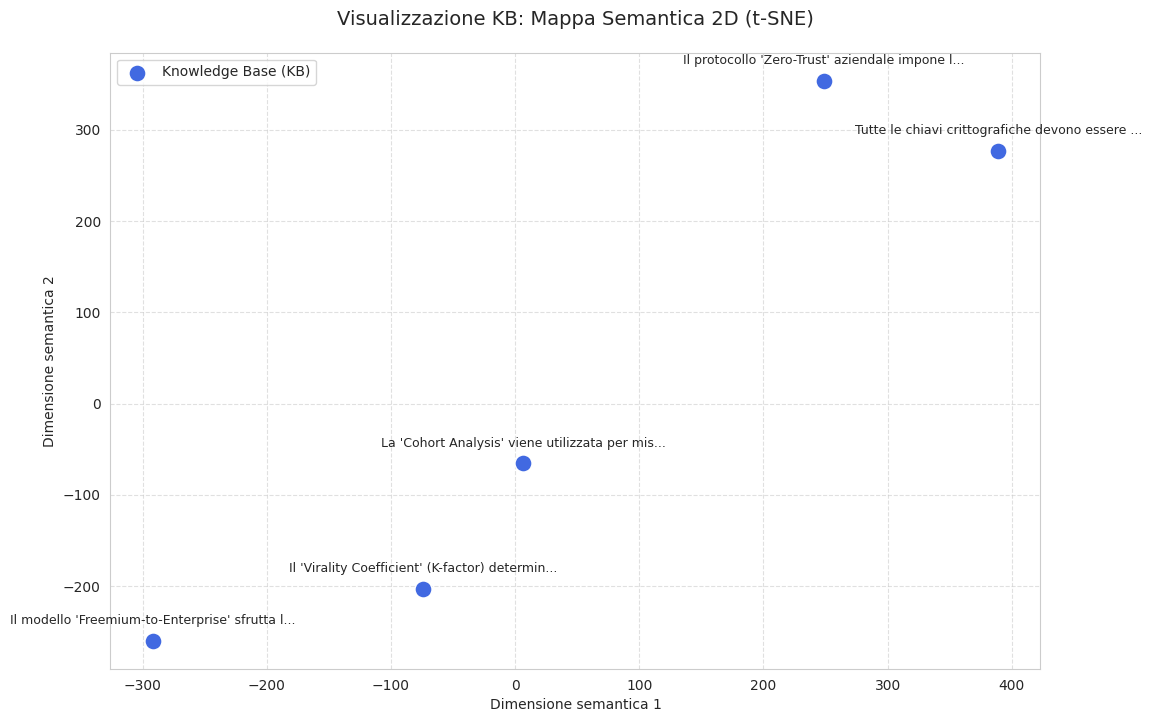


Matrice di similarità interna della KB:
[[1.0000001  0.5424963  0.39554965 0.41726848 0.38637042]
 [0.5424963  1.0000004  0.39007998 0.37863094 0.29614216]
 [0.39554965 0.39007998 1.         0.5243611  0.42200637]
 [0.41726848 0.37863094 0.5243611  0.9999999  0.4090716 ]
 [0.38637042 0.29614216 0.42200637 0.4090716  1.0000001 ]]


In [65]:
# 3. Riduzione dimensionale con t-SNE (Pre-visualizzazione KB)
# Perplexity bassa (2) perché abbiamo pochissimi campioni
tsne = TSNE(n_components=2, perplexity=2, metric = 'cosine', random_state=42, init='random', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

# 4. Plotting della Knowledge Base
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Disegniamo i vertici blu
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], s=150, color='royalblue', label='Knowledge Base (KB)')

# Annotazioni ottimizzate per evitare sovrapposizioni
for i, label in enumerate(sentences):
    # Accorciamo le etichette per il plot
    display_label = (label[:45] + '...') if len(label) > 45 else label
    plt.annotate(display_label,
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 textcoords="offset points",
                 xytext=(0, 12),
                 ha='center',
                 fontsize=9)

plt.title("Visualizzazione KB: Mappa Semantica 2D (t-SNE)", fontsize=14, pad=20)
plt.xlabel("Dimensione semantica 1")
plt.ylabel("Dimensione semantica 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Check Matrice di Similarità
print("\nMatrice di similarità interna della KB:")
print(cosine_similarity(embeddings))

# Fase di Retrival

1. Si estrae l'embedding dalla query utente con lo stesso modello
2. Si calcola la similarità con gli embeddings presenti nella knowledge base e si cerca quello più "vicino" secondo la metrica di similarità per coseno
3. Inseriamo la query nel grafico di rappresentazione dello spazio vettoriale

In [66]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
# Inizializziamo il modello di embedding (se non è già in memoria)
from FlagEmbedding import BGEM3FlagModel


query = "Non riesco più ad accedere alla rete aziendale, come posso fare?"
# 1. Encoding della query
query_output = embed_model.encode([query], return_dense=True)
query_embedding = np.array(query_output['dense_vecs'])

# 2. Calcolo della similarità
similarities = cosine_similarity(query_embedding, embeddings)
best_idx = np.argmax(similarities)
context = sentences[best_idx]

print(f"Query: {query}")
print(f"Documento più rilevante trovato: {context} (Score: {similarities[0][best_idx]:.4f})")

Query: Non riesco più ad accedere alla rete aziendale, come posso fare?
Documento più rilevante trovato: Il protocollo 'Zero-Trust' aziendale impone la ri-autenticazione biometrica ogni 4 ore di inattività sulla VPN. (Score: 0.4701)


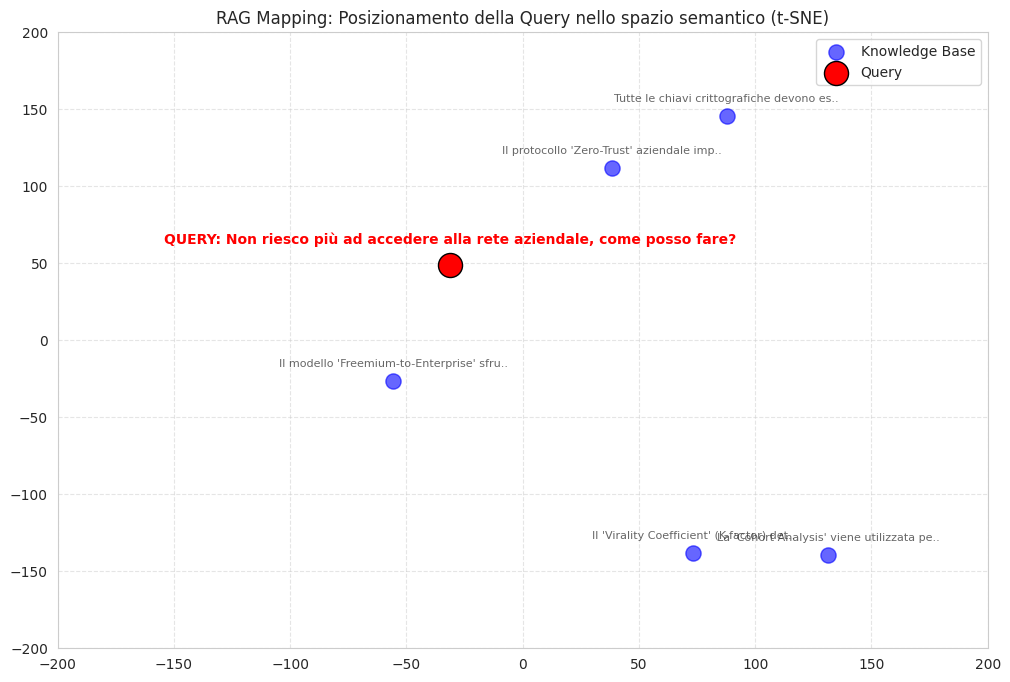

In [67]:
# 1. Uniamo KB e Query (Calcolata in precedenza)
all_embeddings = np.vstack([embeddings, query_embedding])

# 2. Riduzione della dimensionalità con t-SNE
# Manteniamo perplexity bassa (es. 2) perché il dataset è minuscolo
tsne = TSNE(n_components=2, perplexity=2, metric = 'cosine', random_state=42, init='random', learning_rate='auto')
all_2d = tsne.fit_transform(all_embeddings)

# Separiamo nuovamente i punti trasformati
kb_2d = all_2d[:-1]    # Tutti i punti tranne l'ultimo (KB)
query_2d = all_2d[-1:] # Solo l'ultimo punto (la query)

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Punti della Knowledge Base (Blu)
plt.scatter(kb_2d[:, 0], kb_2d[:, 1], s=120, color='blue', alpha=0.6, label='Knowledge Base')

# Punto della Query (Rosso - Vertice evidenziato)
plt.scatter(query_2d[:, 0], query_2d[:, 1], color='red', s=300, marker='o', label='Query', edgecolors='black', zorder=5)

# 4. Annotazioni per la KB
for i, label in enumerate(sentences):
    # Accorciamo per non sovrapporre troppo
    short_label = (label[:40] + '..') if len(label) > 40 else label
    plt.annotate(short_label, (kb_2d[i, 0], kb_2d[i, 1]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, alpha=0.7)

# 5. Annotazione per la Query (In rosso grassetto)
plt.annotate(f"QUERY: {query}", (query_2d[0, 0], query_2d[0, 1]),
             textcoords="offset points", xytext=(0,15), ha='center', color='red', weight='bold')

plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.title("RAG Mapping: Posizionamento della Query nello spazio semantico (t-SNE)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Fase di Augmented Generation
1. Carichiamo un modello LLM come Qwen
2. Costruiamo un system prompt a cui passiamo la query utente e il "documento" più rilevante associato alla query
3. Passiamo il prompt al LLM chiedendo di generare una risposta contestualizzata per l'utente finale

In [70]:
# Scegliamo un modello compatto (Qwen2.5 è ottimo e leggero)
model_id = "Qwen/Qwen2.5-0.5B"

# Caricamento del generatore
generator = pipeline(
    "text-generation",
    model=model_id,
    max_new_tokens=150,
    return_full_text=False,
    device_map="auto",
    trust_remote_code=True
)

# Costruzione del Prompt
prompt = f"#ROLE# Sei un esperto assistente aziendale. # TASKS# Usa solo il seguente contesto per rispondere alla domanda.\n\nContesto: {context}\n\nDomanda: {query}\n\nRisposta:"
print(f"\n--- PROMPT --- \n : {prompt}")
# Generazione
outputs = generator(prompt, do_sample=True, temperature=0.1, repetition_penalty=1.1)
print("\n--- RISPOSTA DELL'LLM ---")
print(outputs[0]['generated_text'].split("Risposta:")[-1].strip())


--- PROMPT --- 
 : #ROLE# Sei un esperto assistente aziendale. # TASKS# Usa solo il seguente contesto per rispondere alla domanda.

Contesto: Il protocollo 'Zero-Trust' aziendale impone la ri-autenticazione biometrica ogni 4 ore di inattività sulla VPN.

Domanda: Non riesco più ad accedere alla rete aziendale, come posso fare?

Risposta:

--- RISPOSTA DELL'LLM ---
La rete aziendale è una parte importante della tua azienda e non puoi farla perdere. Per poter accedere a questa rete senza problemi, dovresti controllare i seguenti passaggi:

1. Controlla l'accesso al server aziendale: Puoi controllare se il server aziendale è attivo e che il server sia disponibile. Utilizza il comando `ping` o `telnet` per controllare l'accesso al server aziendale.
2. Controlla le impostazioni del server aziendale: Puoi controllare le impostazioni del server aziendale per vedere se sono state modificate da parte dell'azienda. Utilizza il


# Conclusione

* In questo breve esperimento possiamo notare che la query utente si posiziona "vicina" nello spazio vettoriale al documento che tratta di **sicurezza informatica**, ciò implica che documento sarà essenziale per poter rispondere in modo coerente.

* Partendo da tale documento il nostro LLM genera un risposta strutturata ed efficace, aggiungendo un suggerimento

>



